### Stan Model (different priors)

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
import os
import arviz as az

# Import functions
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions

# Create ./stan folder if does not exists
if not os.path.exists("./stan"):
    os.mkdir("./stan")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import cmdstanpy
print(cmdstanpy.cmdstan_path())

/Users/sararedaelli/.cmdstan/cmdstan-2.37.0


In [13]:
#get the data
data=pd.read_csv("/Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/data.csv")
print(data.head())
data_donors=pd.read_csv("/Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/data_donatori.csv")
print(data_donors.head())

#remember to drom TMTC and outliers!!!!   (TO DO)

#data cleaning 
data=data[data['Conta']!='TMTC']
print(data.head())
data_donors=data_donors[data_donors['Conta']!='TMTC']
print(data_donors.head())

  Idx Experiment  Idx Replica Diluizione Idx Replica Condizione Controllo  \
0              1                       1                      A        No   
1              1                       2                      A        No   
2              1                       3                      A        No   
3              1                       1                      A        No   
4              1                       2                      A        No   

   Diluition   IBU  DMSO  Temp Conta  
0         -1  6.25     0    28  TMTC  
1         -1  6.25     0    28  TMTC  
2         -1  6.25     0    28  TMTC  
3         -2  6.25     0    28    36  
4         -2  6.25     0    28    33  
  Idx Experiment  Idx Replica Diluizione  Diluition   IBU  DMSO  Temp  Conta
0              1                       1         -6  6.25     0    28     51
1              1                       2         -6  6.25     0    28     48
2              1                       3         -6  6.25     0    28   

In [14]:
#dimensions and colunms
print("data_trasconjugant shape:", data.shape)
print("data_trasconjugant columns:", data.columns.tolist())
print("data_donors shape:", data_donors.shape)
print("data_donors columns:", data_donors.columns.tolist())

data_trasconjugant shape: (378, 9)
data_trasconjugant columns: ['Idx Experiment', 'Idx Replica Diluizione', 'Idx Replica Condizione', 'Controllo', 'Diluition', 'IBU', 'DMSO', 'Temp', 'Conta']
data_donors shape: (72, 7)
data_donors columns: ['Idx Experiment', 'Idx Replica Diluizione', 'Diluition', 'IBU', 'DMSO', 'Temp', 'Conta']


In [15]:
#Rename columns
data.rename(columns={'Idx Replica Condizione': 'Idx Replica Experiment','Controllo':'Control','Idx Replica Diluizione':'Idx Replica Diluition','Conta':'Count'}, inplace=True)
data_donors.rename(columns={'Idx Replica Diluizione':'Idx Replica Experiment','Conta':'Count'}, inplace=True)

#Modify values in some columns:
#Modify Idx Experiment such that experiments 5 and 6 have the same idx, experiments 7 and 8, experiment 5,6 has the same index as 5 and 6 and experiment 7,8 the same as 7 and 8
#but first convert all to string to avoid problems with mixed types
data['Idx Experiment'] = data['Idx Experiment'].astype(str)
data['Idx Experiment'] = data['Idx Experiment'].replace({'6': '5', '7':'6','8': '6', '9':'7','10':'8','5,6': '5', '7,8':'6'})
#now reconvert to numeric
data['Idx Experiment'] = pd.to_numeric(data['Idx Experiment'])

data_donors['Idx Experiment'] = data_donors['Idx Experiment'].astype(str)
data_donors['Idx Experiment'] = data_donors['Idx Experiment'].replace({'6': '5', '7':'6','8': '6', '9':'7','10':'8','5,6': '5', '7,8':'6'})

#modify control column: convert 'Yes' to 1 and 'No' to 0
data['Control'] = data['Control'].replace({'Yes': 1, 'No': 0})



#now reconvert to numeric
data_donors['Idx Experiment'] = pd.to_numeric(data_donors['Idx Experiment'])

print(data['Idx Experiment'].unique())
print(data_donors['Idx Experiment'].unique())

#convert to numeric all the others columns I need 
#convert A;B;C in 1;2;3
data['Idx Replica Experiment'] = data['Idx Replica Experiment'].astype(str)
data['Idx Replica Experiment'] = data['Idx Replica Experiment'].replace({'A': '1', 'B':'2','C': '3'})
#now reconvert to numeric
data['Idx Replica Experiment'] = pd.to_numeric(data['Idx Replica Experiment'])

data['Count'] = pd.to_numeric(data['Count'])
data['Idx Replica Diluition'] = pd.to_numeric(data['Idx Replica Diluition'])
data['Diluition'] = pd.to_numeric(data['Diluition'])
data['IBU'] = pd.to_numeric(data['IBU'])
data['DMSO'] = pd.to_numeric(data['DMSO'])
data['Temp'] = pd.to_numeric(data['Temp'])
data_donors['Count'] = pd.to_numeric(data_donors['Count'])
data_donors['Idx Replica Experiment'] = pd.to_numeric(data_donors['Idx Replica Experiment'])    
print(data.dtypes)
print(data_donors.dtypes)

[1 2 3 4 5 6 7 8]
[1 2 3 4 5 6 7 8]
Idx Experiment              int64
Idx Replica Diluition       int64
Idx Replica Experiment      int64
Control                     int64
Diluition                   int64
IBU                       float64
DMSO                        int64
Temp                        int64
Count                       int64
dtype: object
Idx Experiment              int64
Idx Replica Experiment      int64
Diluition                   int64
IBU                       float64
DMSO                        int64
Temp                        int64
Count                       int64
dtype: object


/var/folders/17/4ypkwf497x10dw9zl6kjtsg80000gn/T/ipykernel_14584/2101165294.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Control'] = data['Control'].replace({'Yes': 1, 'No': 0})


In [17]:
print(np.unique(data['Idx Experiment'])) 
print(np.unique(data['Idx Replica Experiment']))

[1 2 3 4 5 6 7 8]
[1 2 3]


In [18]:
data.head()

,Idx Experiment,Idx Replica Diluition,Idx Replica Experiment,Control,Diluition,IBU,DMSO,Temp,Count
3,1,1,1,0,-2,6.25,0,28,36
4,1,2,1,0,-2,6.25,0,28,33
5,1,3,1,0,-2,6.25,0,28,30
6,1,1,1,0,-3,6.25,0,28,4
7,1,2,1,0,-3,6.25,0,28,6


In [19]:
data_donors.head()

,Idx Experiment,Idx Replica Experiment,Diluition,IBU,DMSO,Temp,Count
0,1,1,-6,6.25,0,28,51
1,1,2,-6,6.25,0,28,48
2,1,3,-6,6.25,0,28,50
3,1,1,-7,6.25,0,28,7
4,1,2,-7,6.25,0,28,3


In [20]:
#Extract the data we need for the Stan model 
#from trasconjugant dataset
Y=data.Count.values
N=len(Y)
idx_experiment=data['Idx Experiment'].values
I=len(np.unique(idx_experiment))
idx_experiment_replica=data['Idx Replica Experiment'].values
J=len(np.unique(idx_experiment_replica))
dil_trasc=data['Diluition'].values
rho_trasc = np.power(10.0, dil_trasc)


#from donor dataset
D=data_donors.Count.values
M=len(D)
idx_donor_experiment=data_donors['Idx Experiment'].values
dil_donor=data_donors['Diluition'].values
rho_donor=np.power(10.0, dil_donor)


#build design matrix X
IBU=data['IBU'].values
DMSO=data['DMSO'].values
Temp=data['Temp'].values

#normalize covariates
IBU=(IBU - np.mean(IBU)) / np.std(IBU)
DMSO=(DMSO - np.mean(DMSO)) / np.std(DMSO)
Temp=(Temp - np.mean(Temp)) / np.std(Temp)  

X=np.column_stack([np.ones_like(Y),IBU,DMSO,Temp])

##### Stan Model

In [21]:
glm1 = """
data {
    int<lower=0> N; 
    int<lower=0> M; 
    int<lower=0> p; 
    int<lower=0> I;
    int<lower=0> J;
    array[N] int<lower=0> Y;
    array[M] int<lower=0> D;
    matrix[N, p] X;
    vector[N] rho_trasc;
    vector[M] rho_donor;
    array[N] int idx_experiment;
    array[N] int idx_experiment_replica;
    array[M] int idx_donor_experiment;
}

parameters {
    vector[p] beta;
    matrix[I, J] beta_random;
    vector<lower=0>[I] alpha;
    real<lower=0> sigma_beta_sq;
    real<lower=0> tau_sq;
    real mu_chi;
    real<lower=0> sigma_chi;
}


transformed parameters {
    vector[N] mu;
    for(i in 1:N) {
      mu[i] = alpha[idx_experiment[i]]* exp(row(X, i) * beta + beta_random[idx_experiment[i], idx_experiment_replica[i]]);
    }
    real<lower=0> sigma_beta = sqrt(sigma_beta_sq);
    real<lower=0> tau = sqrt(tau_sq);
}

model {   
    for (s in 1:N) {
        Y[s] ~ poisson(rho_trasc[s] * mu[s]);  

    }

    for (l in 1:M){
        D[l] ~ poisson(rho_donor[l] * alpha[idx_donor_experiment[l]]);
    }

    for (m in 1:I) {
        log(alpha[m])~normal(mu_chi, sigma_chi);

    }
    mu_chi ~ normal(4,1);
    sigma_chi ~ normal(0,1); 
    

    for (k in 1:p) {
        beta[k] ~ normal(0.0, tau);
        
    }

    tau_sq ~ inv_gamma(2, 1); 
    
    for (i in 1:I) {    
        for (j in 1:J) {
            beta_random[i,j] ~ normal(0, sigma_beta);
        }
    }
    sigma_beta_sq ~ inv_gamma(2, 1);  
 
}

generated quantities {
  vector[N] log_lik;
  for (j in 1:N) {
    log_lik[j] = poisson_lpmf(Y[j] | rho_trasc[j]* mu[j]);
  }
}
"""


# Write stan model to file
stan_file = "./stan/glm1.stan"
with open(stan_file, "w") as f:
    print(glm1, file=f)

# Compile stan model
glm1 = CmdStanModel(stan_file=stan_file)

15:42:45 - cmdstanpy - INFO - compiling stan file /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics/src/jupyter/stan/glm1.stan to exe file /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics/src/jupyter/stan/glm1


15:43:20 - cmdstanpy - INFO - compiled model executable: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics/src/jupyter/stan/glm1


In [22]:
# Input data
glm1_data = {
    "N": N,
    "M": M,
    "I":I,
    "J":J,
    "p": X.shape[1],
    "Y": Y,
    "D": D,
    "X": X,
    "rho_trasc": rho_trasc,
    "rho_donor": rho_donor,
    "idx_experiment": idx_experiment,
    "idx_experiment_replica": idx_experiment_replica,
    "idx_donor_experiment": idx_donor_experiment
}

# Sample
glm1_fit = glm1.sample(data=glm1_data, chains=4, parallel_chains=4, 
                             iter_warmup=1000, iter_sampling=5000,show_console=True)

# Convert to arviz data type
poi_glm1_data = az.from_cmdstanpy(glm1_fit)

15:43:25 - cmdstanpy - INFO - Chain [1] start processing
15:43:25 - cmdstanpy - INFO - Chain [2] start processing
15:43:25 - cmdstanpy - INFO - Chain [3] start processing
15:43:25 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 5000
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/17/4ypkwf497x10dw9zl6kjtsg80000gn/T/tmpptrny274/u_mz4nst.json
Chain [1] init = 2 (Default)
Chain [1] ra

15:46:49 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 30.077 seconds (Warm-up)
Chain [2] 173.218 seconds (Sampling)
Chain [2] 203.295 seconds (Total)
Chain [2] 
Chain [2] 
Chain [4] Iteration: 5700 / 6000 [ 95%]  (Sampling)
Chain [1] Iteration: 5800 / 6000 [ 96%]  (Sampling)
Chain [3] Iteration: 5900 / 6000 [ 98%]  (Sampling)
Chain [4] Iteration: 5800 / 6000 [ 96%]  (Sampling)
Chain [1] Iteration: 5900 / 6000 [ 98%]  (Sampling)
Chain [3] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 33.104 seconds (Warm-up)
Chain [3] 173.196 seconds (Sampling)
Chain [3] 206.3 seconds (Total)
Chain [3] 
Chain [3] 


15:46:52 - cmdstanpy - INFO - Chain [3] done processing


Chain [4] Iteration: 5900 / 6000 [ 98%]  (Sampling)


15:46:54 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 37.353 seconds (Warm-up)
Chain [1] 170.759 seconds (Sampling)
Chain [1] 208.112 seconds (Total)
Chain [1] 
Chain [1] 


15:46:54 - cmdstanpy - INFO - Chain [4] done processing
15:46:54 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'glm1.stan', line 49, column 8 to column 48)
Exception: poisson_lpmf: Rate parameter is nan, but must be nonnegative! (in 'glm1.stan', line 40, column 8 to column 45)
	Exception: poisson_lpmf: Rate parameter is nan, but must be nonnegative! (in 'glm1.stan', line 40, column 8 to column 45)


Chain [4] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 40.462 seconds (Warm-up)
Chain [4] 168.473 seconds (Sampling)
Chain [4] 208.935 seconds (Total)
Chain [4] 
Chain [4] 


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (28), generating only 20 plots
  warnings.warn(


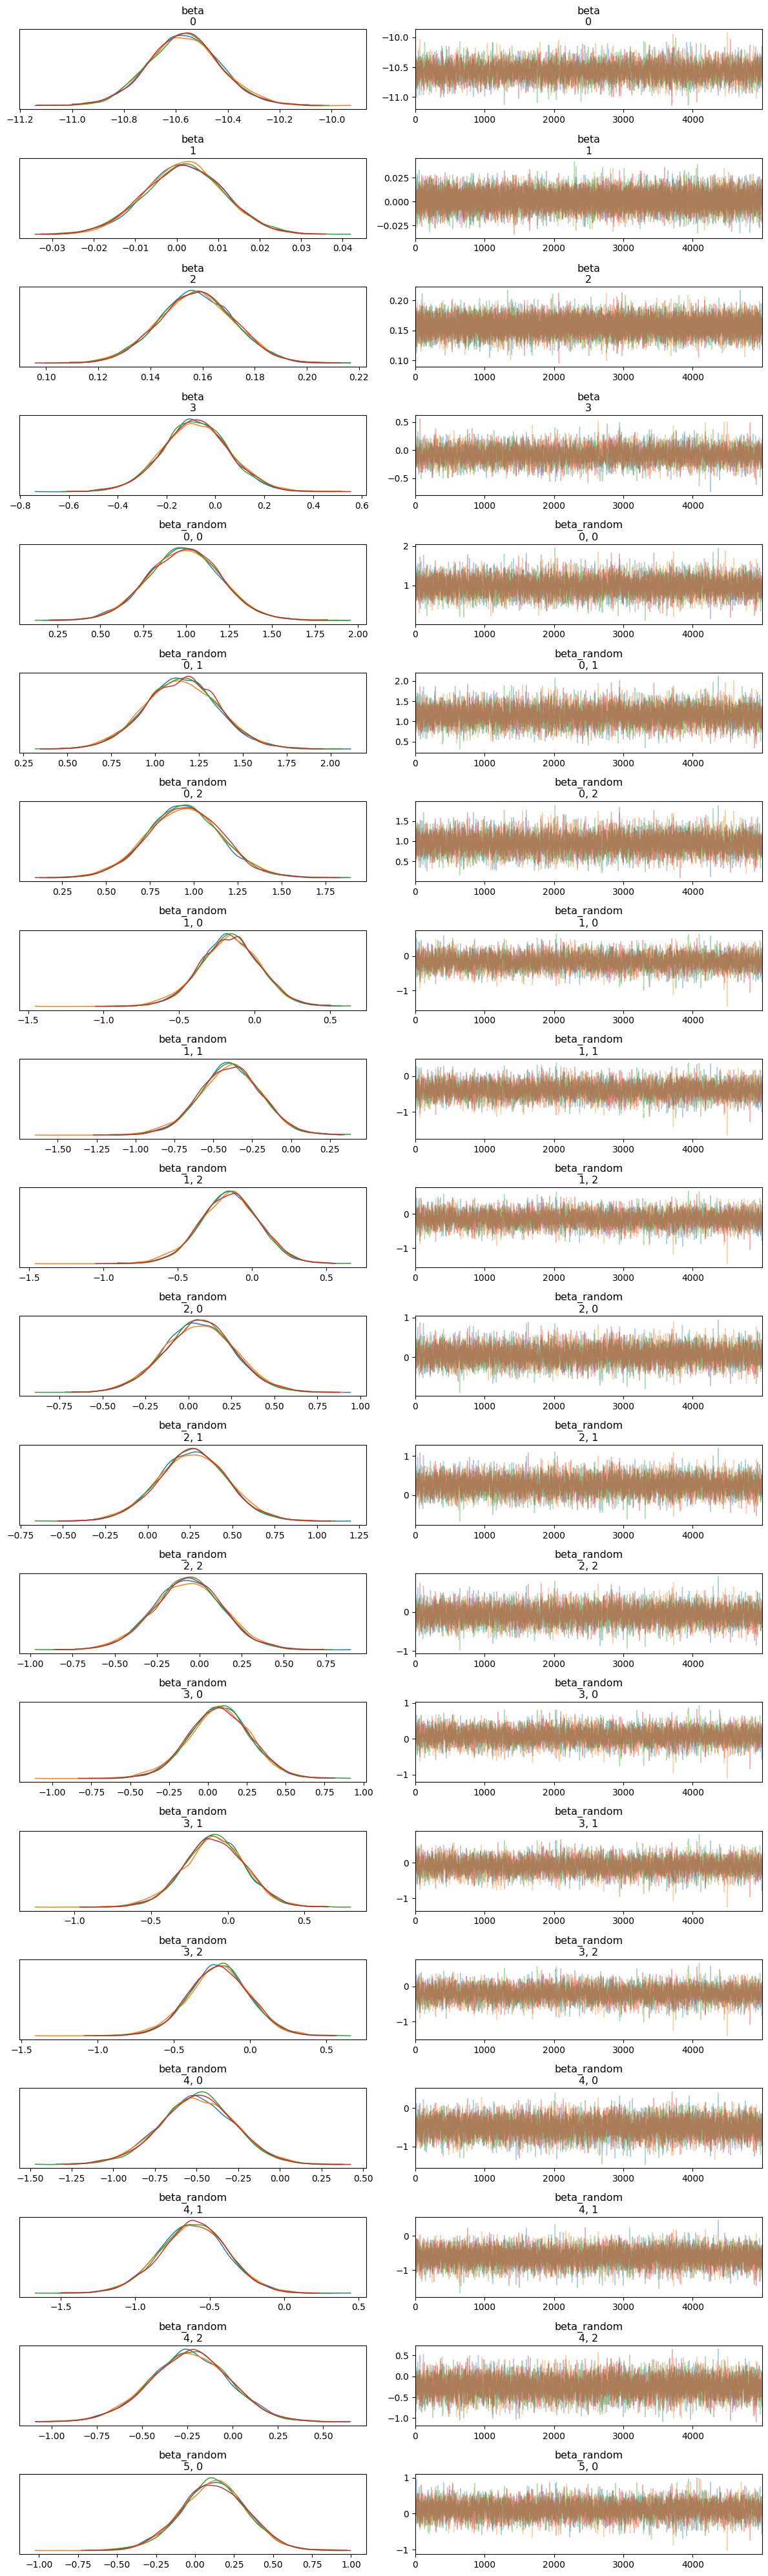

In [23]:
az.plot_trace(poi_glm1_data, var_names=["beta", "beta_random"], compact=False)
plt.tight_layout()
plt.show()

divergence <xarray.DataArray 'diverging' ()> Size: 8B
array(0)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (112) in plot_autocorr, generating only 40 plots
  warnings.warn(


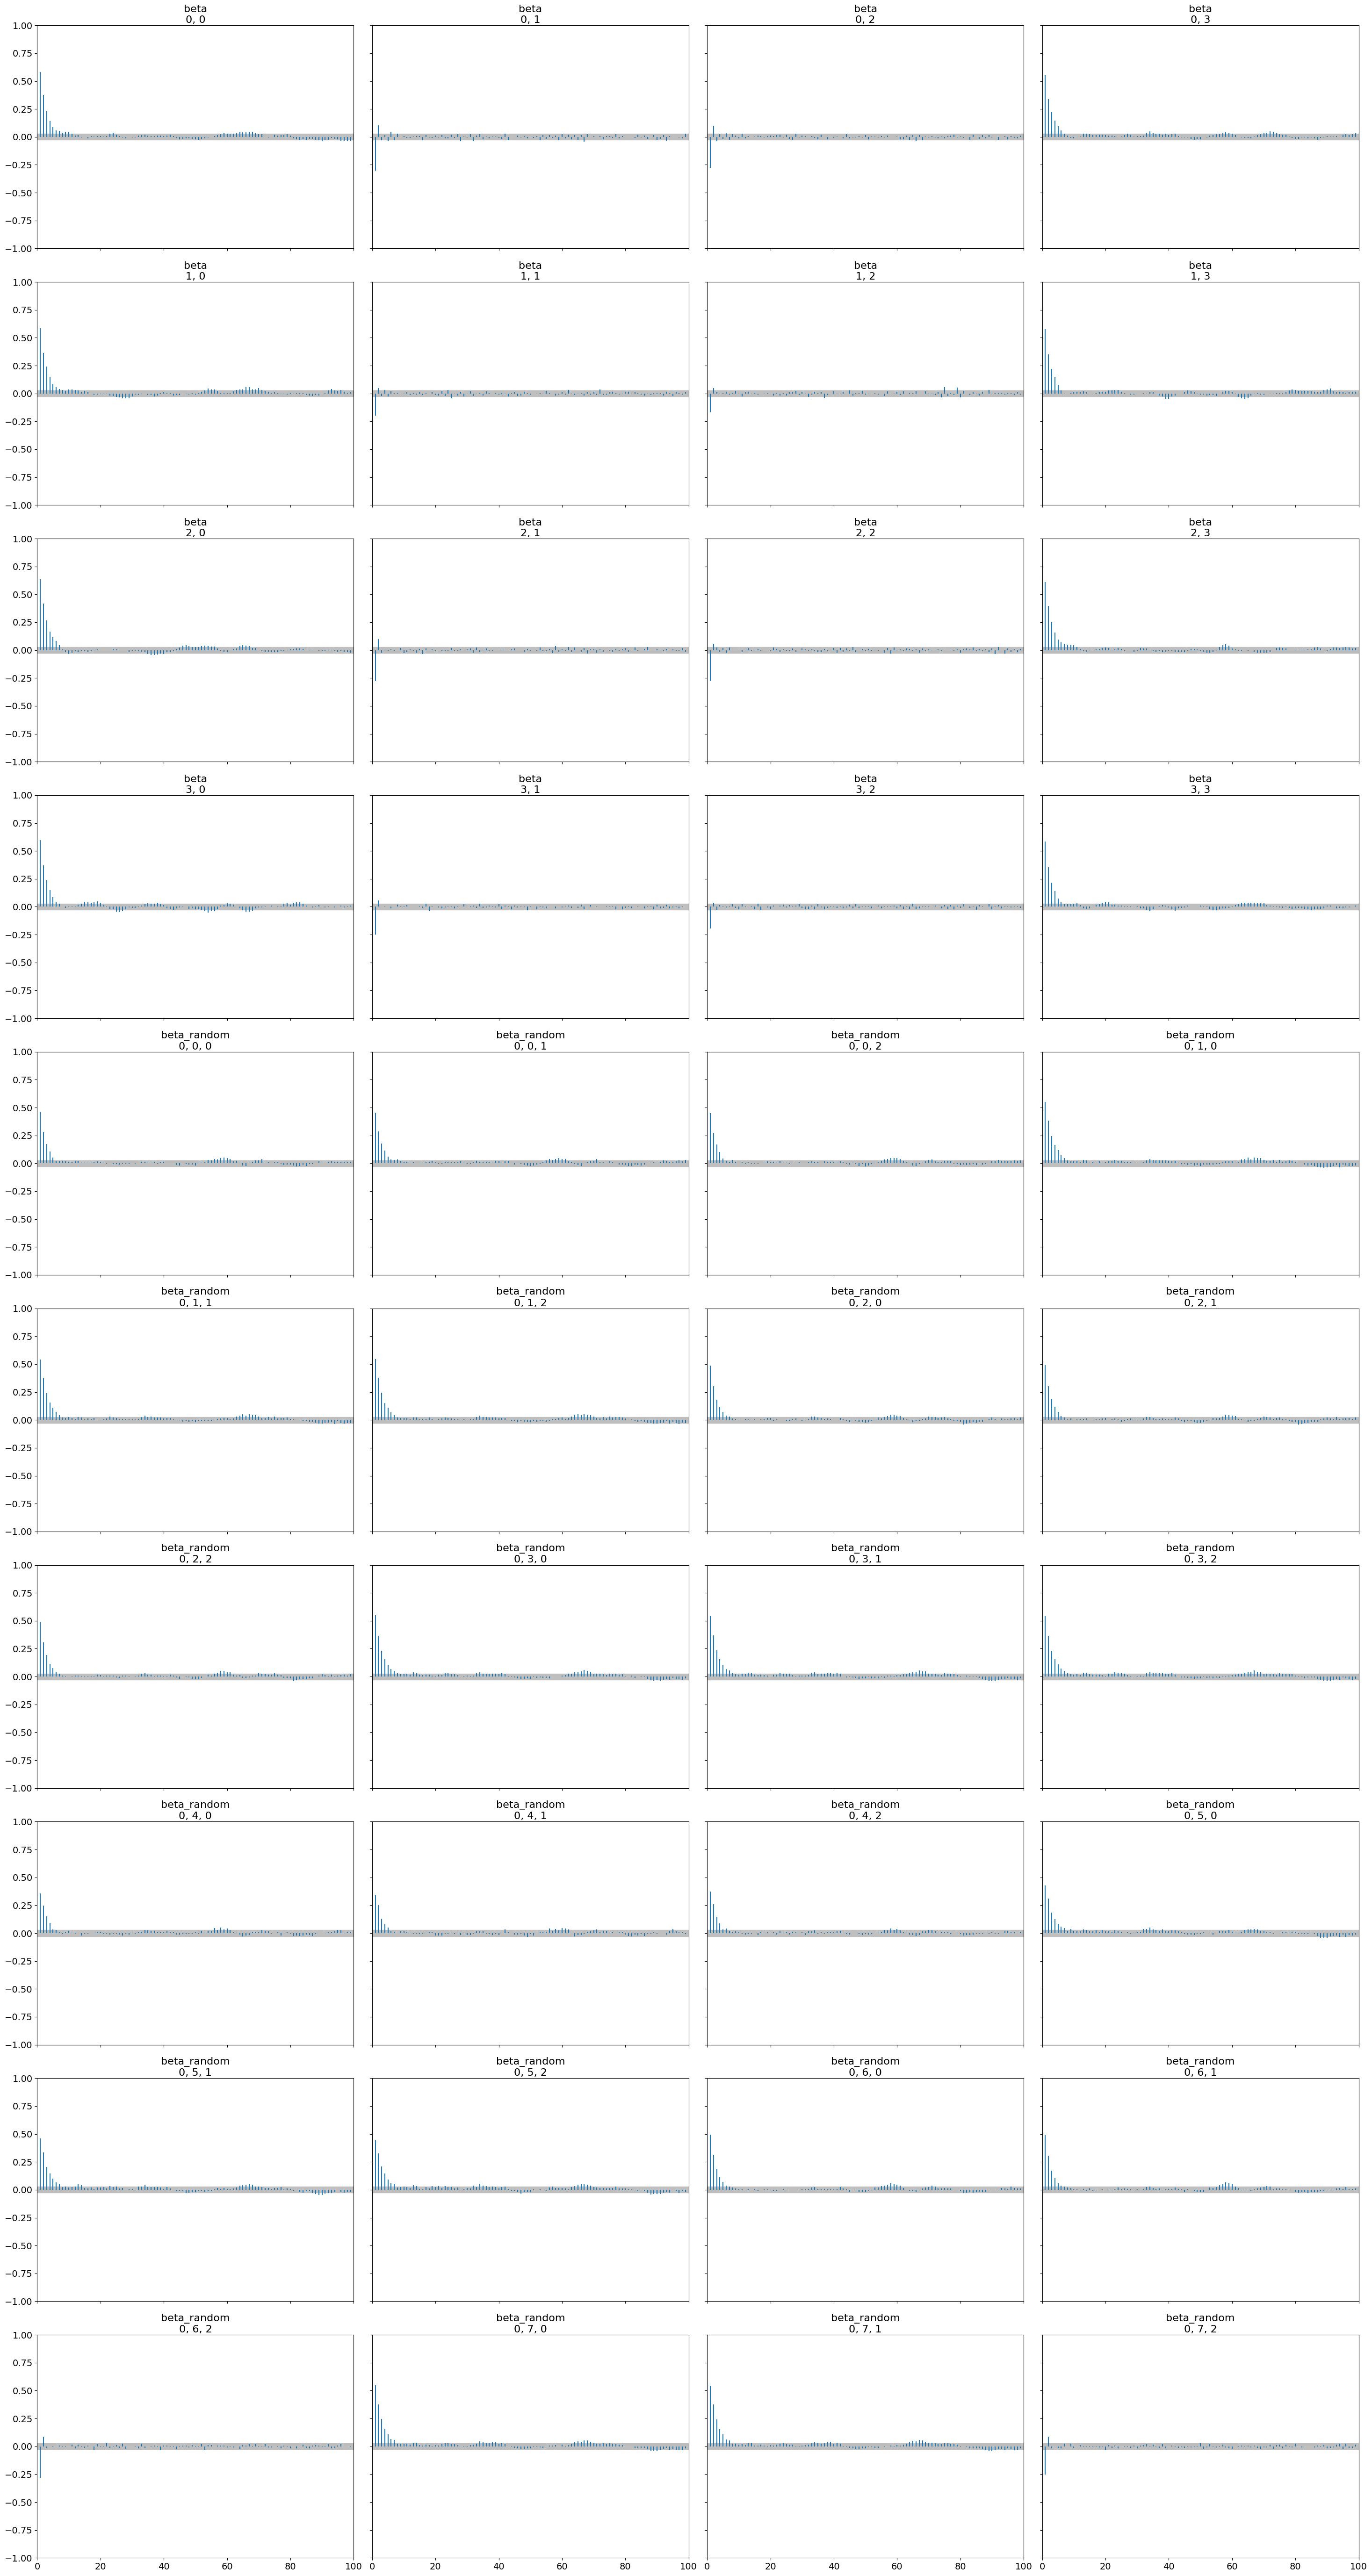

In [24]:
#check MCMC chain
print("divergence",np.sum(poi_glm1_data.sample_stats.diverging))
#no divergence!!!!

#plot the autocorrelation plots
az.plot_autocorr(poi_glm1_data, var_names=["beta", "beta_random"])
plt.tight_layout()
plt.show() 




In [25]:
#EFFECTIVE SAMPLE SIZE for all parameters
ess = az.ess(poi_glm1_data)

# vettore ESS per beta
ess_beta = ess["beta"].values
print("ESS beta:", ess_beta)

# matrice ESS per beta_random
ess_br = ess["beta_random"].values
print("ESS beta_random shape:", ess_br.shape)
print(ess_br)

#vettore ESS per alpha
ess_alpha = ess["alpha"].values
print("ESS alpha:", ess_alpha)

#ESS per tau_sq
ess_tau_sq = ess["tau_sq"].values
print("ESS tau_sq:", ess_tau_sq)

#ESS per sigma_beta_sq
ess_sigma_beta_sq = ess["sigma_beta_sq"].values
print("ESS sigma_beta_sq:", ess_sigma_beta_sq)

#ESS per mu_chi
ess_mu_chi = ess["mu_chi"].values
print("ESS mu_chi:", ess_mu_chi)

#ESS per sigma_chi
ess_sigma_chi = ess["sigma_chi"].values
print("ESS sigma_chi:", ess_sigma_chi)



ESS beta: [ 4540.2720365  32504.14895118 29485.89890971  4751.23438235]
ESS beta_random shape: (8, 3)
[[ 5758.52117419  5452.60308797  5909.38956146]
 [ 4414.76759474  4420.60269929  4432.308787  ]
 [ 5435.44729337  5457.67560005  5458.03358778]
 [ 4404.61743518  4409.05538363  4413.04839115]
 [ 6722.2601217   6606.84392282  6510.00674038]
 [ 4758.64320141  4687.92516238  4723.25221794]
 [ 5364.02696919  5490.48920015 28077.54028129]
 [ 4444.54896167  4461.67733574 26929.57820607]]
ESS alpha: [27665.18581266 29317.74379531 26910.91492224 30736.03710426
 29340.58228866 28690.75812692 30384.63590136 30489.11208209]
ESS tau_sq: 27561.134525553676
ESS sigma_beta_sq: 17651.924681712484
ESS mu_chi: 26351.764932406862
ESS sigma_chi: 26341.80795165859


##### Posterior confidence intervals 

In [28]:
glm1_fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68878.800000,0.054120,4.641070,4.553810,68870.500000,68879.300000,68885.800000,7484.81,11616.30,10.91640,1.000550
beta[1],-10.568200,0.002105,0.141199,0.137022,-10.797800,-10.569000,-10.332900,4540.27,6099.11,6.62189,1.000590
beta[2],0.001887,0.000053,0.009585,0.009540,-0.013920,0.001895,0.017827,32504.10,13611.30,47.40660,1.000150
beta[3],0.157580,0.000085,0.014503,0.014453,0.133585,0.157557,0.181447,29485.90,15142.30,43.00460,1.000050
beta[4],-0.082235,0.002013,0.138708,0.134441,-0.308011,-0.083912,0.148059,4751.23,7149.50,6.92957,1.000980
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.543530,0.001070,0.139236,0.095236,-2.823250,-2.495850,-2.421860,20046.70,15820.50,29.23770,0.999861
log_lik[375],-3.195010,0.002797,0.400665,0.389198,-3.918490,-3.148000,-2.620840,20870.10,15820.70,30.43860,0.999866
log_lik[376],-2.178410,0.001038,0.149873,0.149307,-2.428320,-2.174980,-1.936190,20870.10,15820.70,30.43860,0.999866
log_lik[377],-1.402190,0.000562,0.081083,0.080360,-1.541120,-1.397960,-1.275470,20870.10,15820.70,30.43860,0.999866


array([<Axes: title={'center': 'beta\n0'}>,
       <Axes: title={'center': 'beta\n1'}>,
       <Axes: title={'center': 'beta\n2'}>,
       <Axes: title={'center': 'beta\n3'}>], dtype=object)

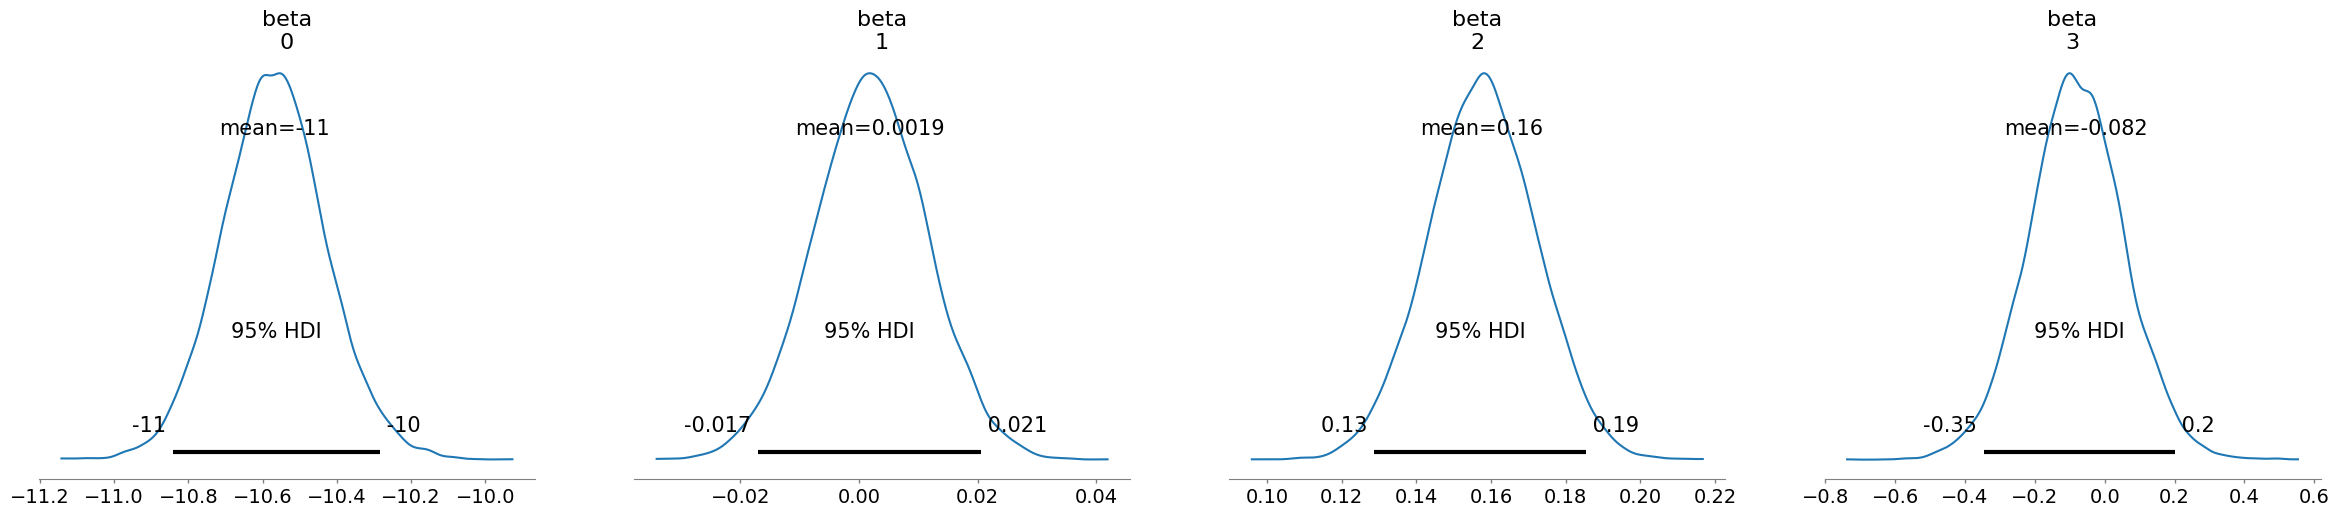

In [29]:
#plot posterior for beta
az.plot_posterior(poi_glm1_data, var_names=["beta"], hdi_prob=0.95)

array([[<Axes: title={'center': 'beta_random\n0, 0'}>,
        <Axes: title={'center': 'beta_random\n0, 1'}>,
        <Axes: title={'center': 'beta_random\n0, 2'}>,
        <Axes: title={'center': 'beta_random\n1, 0'}>],
       [<Axes: title={'center': 'beta_random\n1, 1'}>,
        <Axes: title={'center': 'beta_random\n1, 2'}>,
        <Axes: title={'center': 'beta_random\n2, 0'}>,
        <Axes: title={'center': 'beta_random\n2, 1'}>],
       [<Axes: title={'center': 'beta_random\n2, 2'}>,
        <Axes: title={'center': 'beta_random\n3, 0'}>,
        <Axes: title={'center': 'beta_random\n3, 1'}>,
        <Axes: title={'center': 'beta_random\n3, 2'}>],
       [<Axes: title={'center': 'beta_random\n4, 0'}>,
        <Axes: title={'center': 'beta_random\n4, 1'}>,
        <Axes: title={'center': 'beta_random\n4, 2'}>,
        <Axes: title={'center': 'beta_random\n5, 0'}>],
       [<Axes: title={'center': 'beta_random\n5, 1'}>,
        <Axes: title={'center': 'beta_random\n5, 2'}>,
      

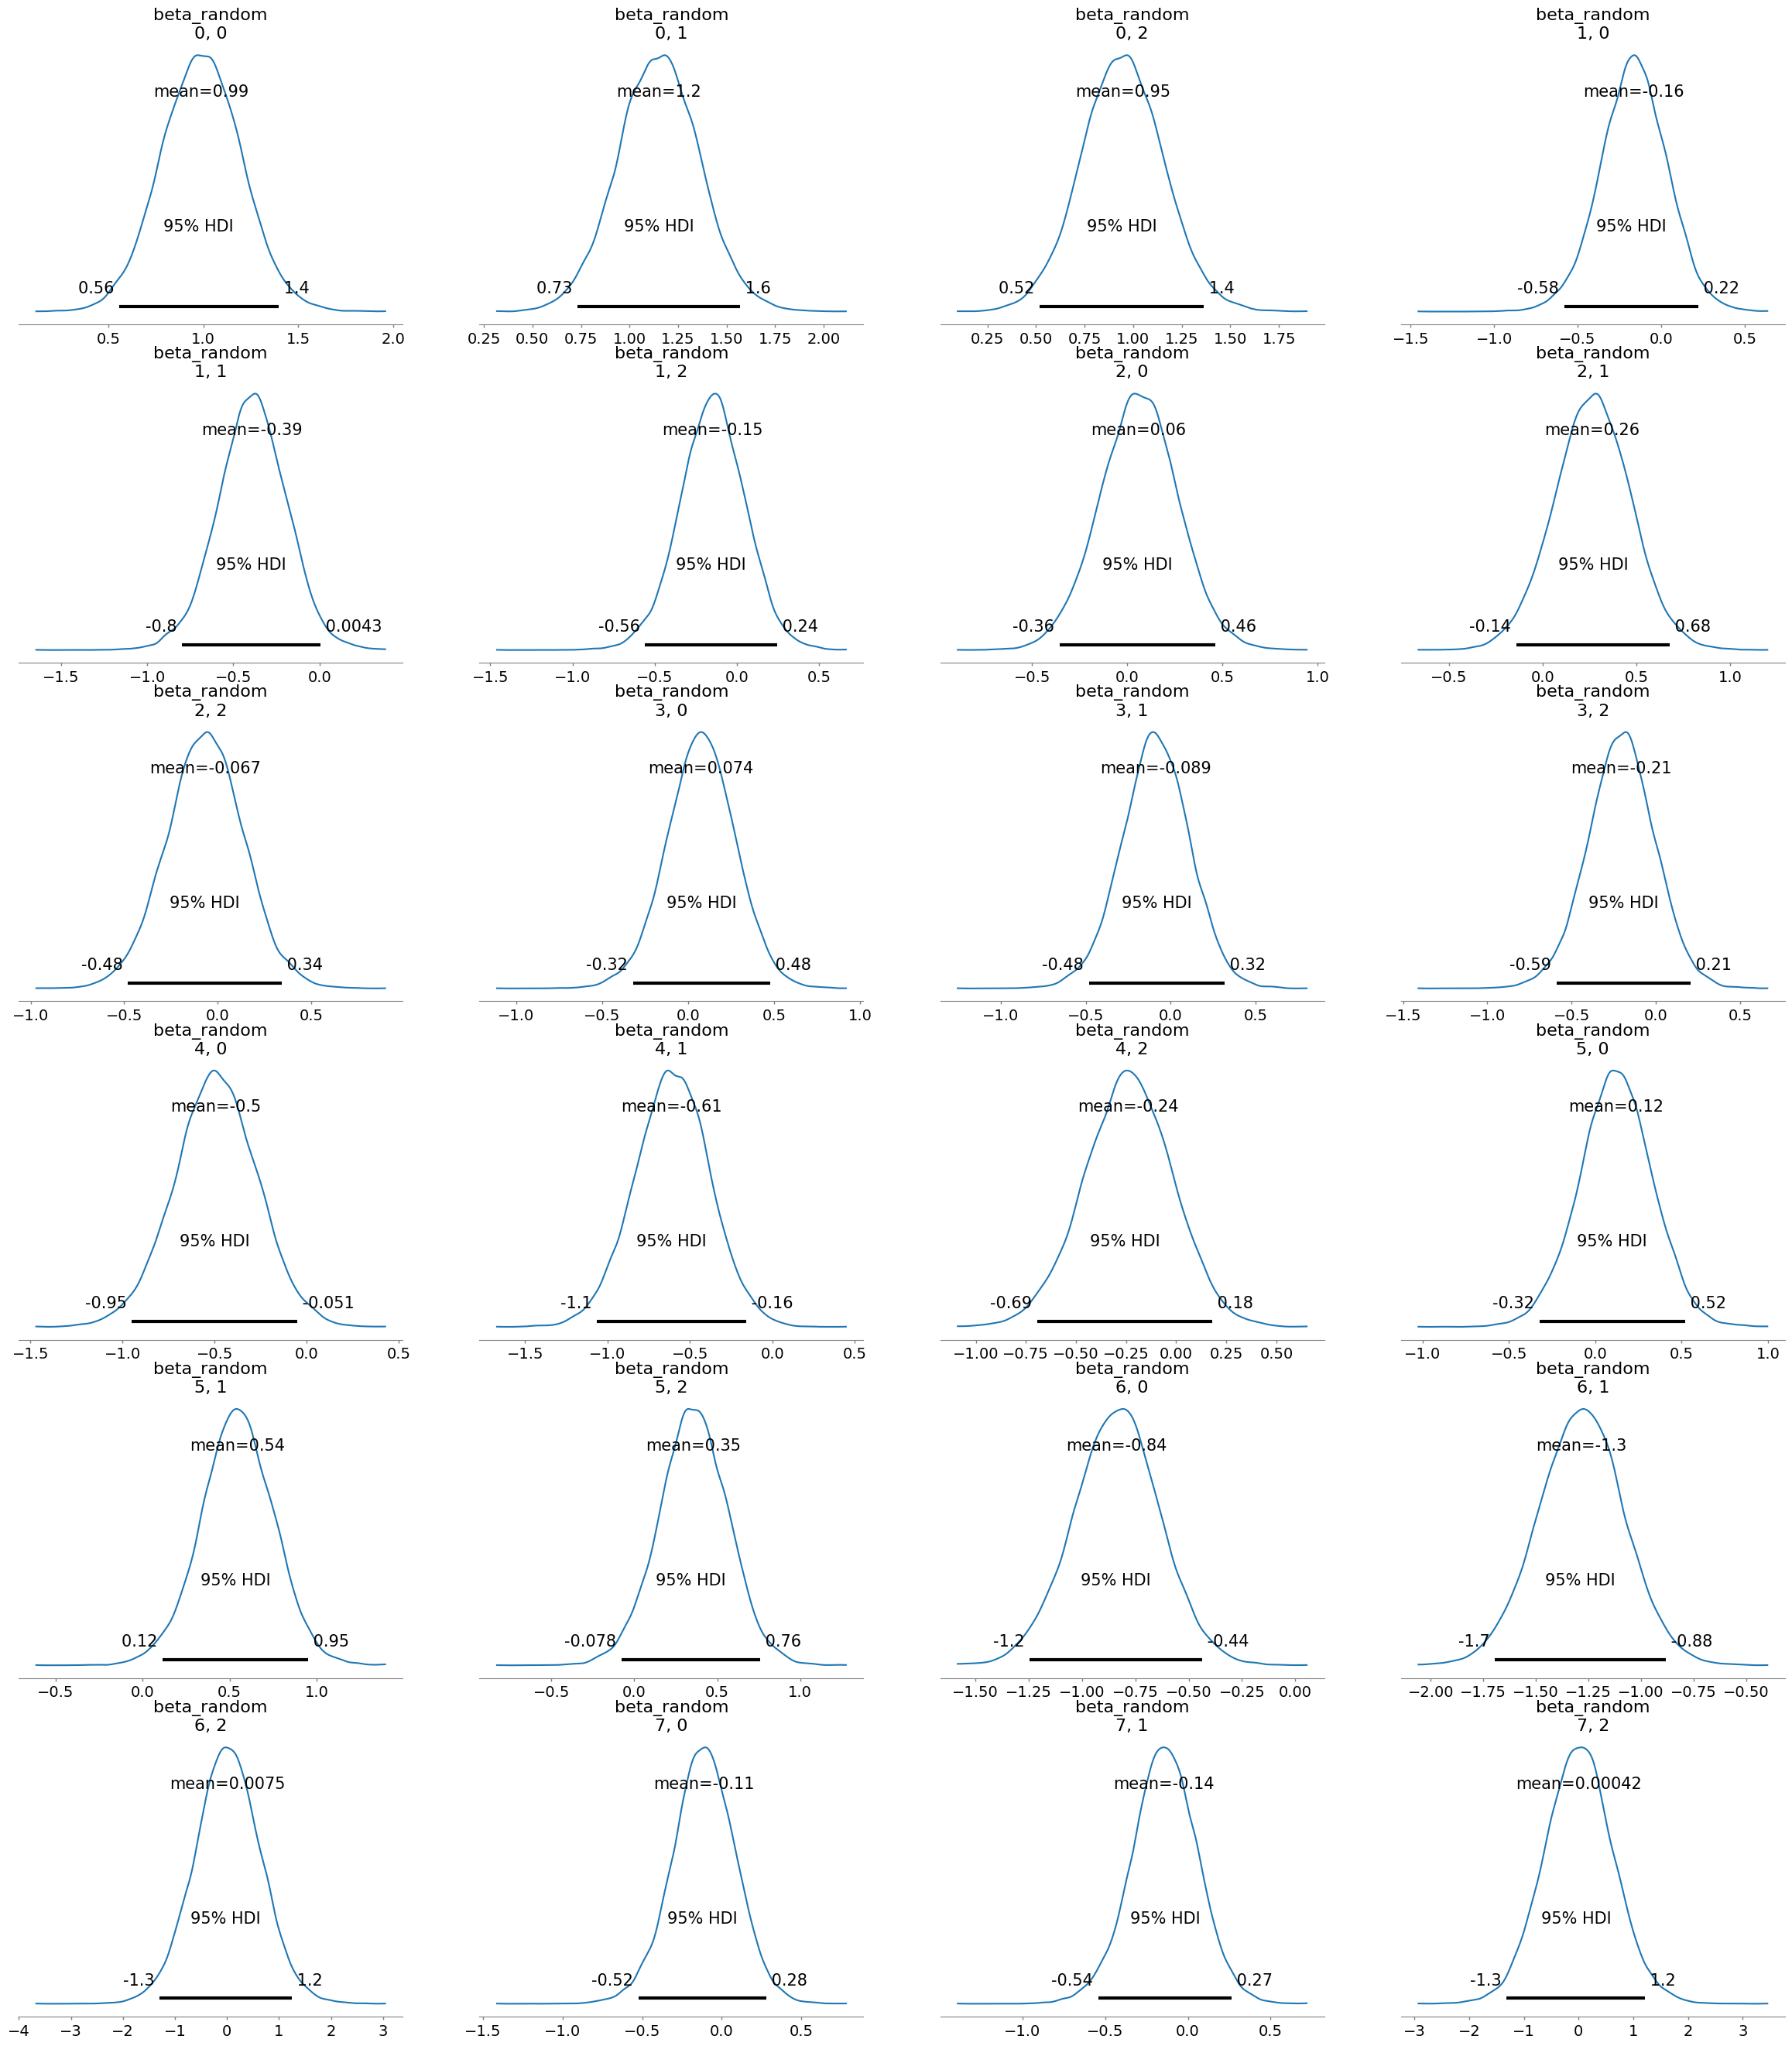

In [30]:
az.plot_posterior(poi_glm1_data, var_names=["beta_random"], hdi_prob=0.95)

array([[<Axes: title={'center': 'alpha\n0'}>,
        <Axes: title={'center': 'alpha\n1'}>,
        <Axes: title={'center': 'alpha\n2'}>,
        <Axes: title={'center': 'alpha\n3'}>],
       [<Axes: title={'center': 'alpha\n4'}>,
        <Axes: title={'center': 'alpha\n5'}>,
        <Axes: title={'center': 'alpha\n6'}>,
        <Axes: title={'center': 'alpha\n7'}>]], dtype=object)

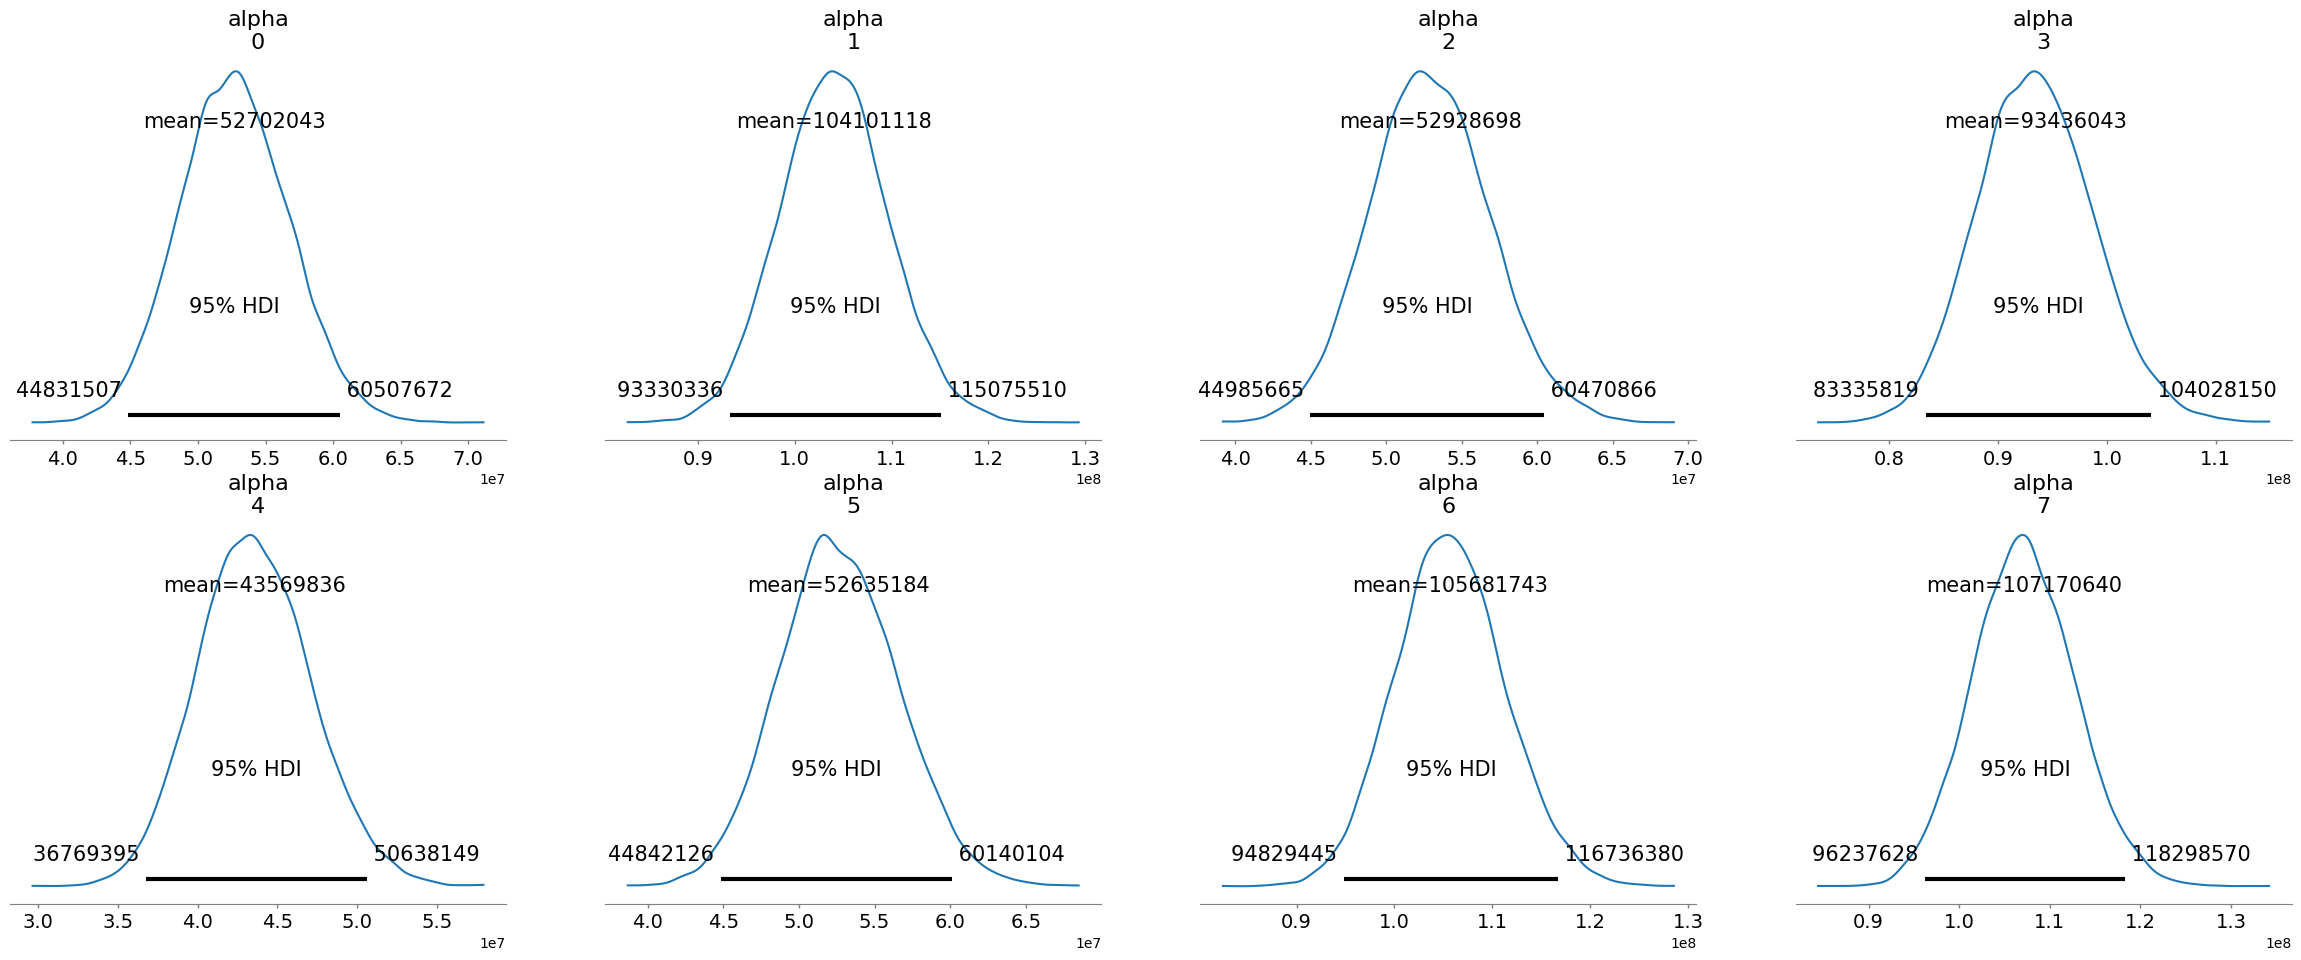

In [31]:
az.plot_posterior(poi_glm1_data, var_names=["alpha"], hdi_prob=0.95)

In [32]:
az.summary(poi_glm1_data, var_names=["beta"], hdi_prob=0.95)
#b0 is the intercept
#b1 is the coefficient for IBU
#b2 is the coefficient for DMSO
#b3 is the coefficient for Temp

#mcse_mean is the Monte Carlo Standard Error of the mean estimate
#mcmse_sd is the Monte Carlo Standard Error of the standard deviation estimate
#ess_bulk is the number of independent samples in the bulk of the posterior(central part of the distribution)
#ess_tail is the number of independent samples in the tails of the posterior(distribution extremes)
#r_hat (Gelman–Rubin diagnostic) convergence diagnostic 


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],-10.568,0.141,-10.842,-10.284,0.002,0.001,4540.0,6099.0,1.0
beta[1],0.002,0.010,-0.017,0.021,0.000,0.000,32504.0,13611.0,1.0
beta[2],0.158,0.015,0.129,0.185,0.000,0.000,29486.0,15142.0,1.0
beta[3],-0.082,0.139,-0.346,0.200,0.002,0.001,4751.0,7149.0,1.0


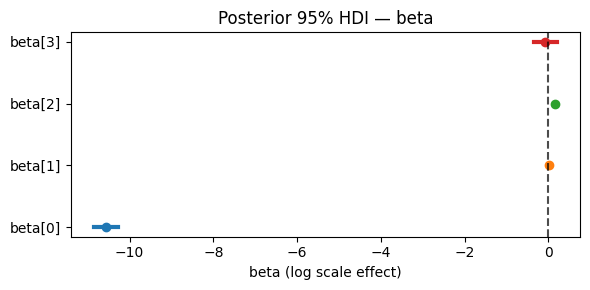

In [33]:
sum_beta = az.summary(poi_glm1_data, var_names=["beta"], hdi_prob=0.95)

names = sum_beta.index.to_list()
mean  = sum_beta["mean"].values
low   = sum_beta["hdi_2.5%"].values
high  = sum_beta["hdi_97.5%"].values
y = np.arange(len(names))

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

plt.figure(figsize=(6, 3))
for i in range(len(names)):
    plt.plot([low[i], high[i]], [y[i], y[i]], lw=3, color=colors[i])
    plt.plot(mean[i], y[i], "o", color=colors[i])

plt.axvline(0, color="black", ls="--", alpha=0.7)
plt.yticks(y, names)
plt.xlabel("beta (log scale effect)")
plt.title("Posterior 95% HDI — beta")
plt.tight_layout()
plt.show()


In [34]:
az.summary(poi_glm1_data, var_names=["beta_random"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"beta_random[0, 0]",0.989,0.213,0.556,1.395,0.003,0.002,5759.0,8960.0,1.0
"beta_random[0, 1]",1.151,0.212,0.733,1.569,0.003,0.002,5453.0,9021.0,1.0
"beta_random[0, 2]",0.946,0.214,0.520,1.362,0.003,0.002,5909.0,9174.0,1.0
"beta_random[1, 0]",-0.165,0.203,-0.579,0.222,0.003,0.002,4415.0,6269.0,1.0
"beta_random[1, 1]",-0.392,0.203,-0.799,0.004,0.003,0.002,4421.0,6544.0,1.0
"beta_random[1, 2]",-0.150,0.203,-0.559,0.244,0.003,0.002,4432.0,6098.0,1.0
"beta_random[2, 0]",0.060,0.208,-0.355,0.462,0.003,0.002,5435.0,8417.0,1.0
"beta_random[2, 1]",0.264,0.207,-0.142,0.678,0.003,0.002,5458.0,8048.0,1.0
"beta_random[2, 2]",-0.067,0.208,-0.480,0.342,0.003,0.002,5458.0,8177.0,1.0
"beta_random[3, 0]",0.074,0.202,-0.321,0.476,0.003,0.002,4405.0,6076.0,1.0


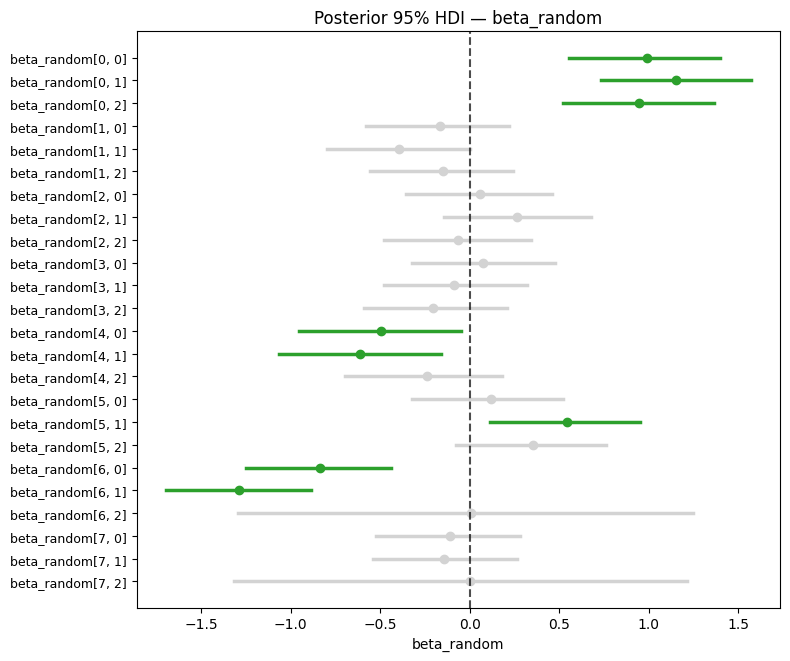

In [35]:
sum_br = az.summary(poi_glm1_data, var_names=["beta_random"], hdi_prob=0.95)

ij = sum_br.index.str.extract(r"beta_random\[(\d+),\s*(\d+)\]").astype(int)
sum_br = sum_br.assign(i=ij[0].values, j=ij[1].values).sort_values(["i", "j"])

labels = sum_br.index.to_list()
mean = sum_br["mean"].values
low = sum_br["hdi_2.5%"].values
high = sum_br["hdi_97.5%"].values
y = np.arange(len(labels))

plt.figure(figsize=(8, max(6, 0.28 * len(labels))))

for k in range(len(labels)):
    color = "tab:green" if (low[k] > 0) or (high[k] < 0) else "lightgray"
    plt.plot([low[k], high[k]], [y[k], y[k]], lw=2.5, color=color)
    plt.plot(mean[k], y[k], "o", color=color)

plt.axvline(0, color="black", ls="--", alpha=0.7)
plt.yticks(y, labels, fontsize=9)
plt.xlabel("beta_random")
plt.title("Posterior 95% HDI — beta_random")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


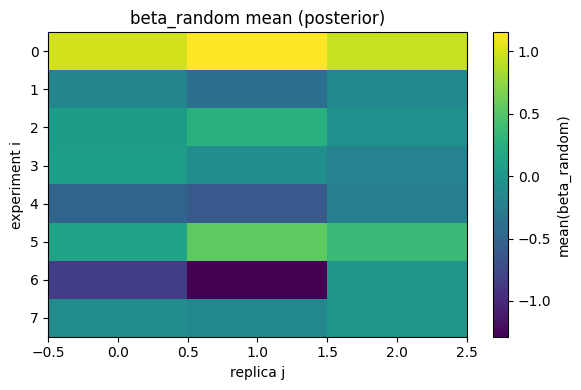

In [36]:
sum_br = az.summary(poi_glm1_data, var_names=["beta_random"], hdi_prob=0.95)

# ricostruisco indici (i,j) parsando il nome "beta_random[6, 2]"
ij = sum_br.index.str.extract(r"beta_random\[(\d+),\s*(\d+)\]").astype(int)
i_idx = ij[0].values
j_idx = ij[1].values

I = i_idx.max() + 1
J = j_idx.max() + 1

mean_mat = np.full((I, J), np.nan)
hdiw_mat = np.full((I, J), np.nan)  # width dell'HDI (incertezza)

for k, (i, j) in enumerate(zip(i_idx, j_idx)):
    mean_mat[i, j] = sum_br["mean"].values[k]
    hdiw_mat[i, j] = sum_br["hdi_97.5%"].values[k] - sum_br["hdi_2.5%"].values[k]

plt.figure(figsize=(6, 4))
plt.imshow(mean_mat, aspect="auto")
plt.colorbar(label="mean(beta_random)")
plt.xlabel("replica j")
plt.ylabel("experiment i")
plt.title("beta_random mean (posterior)")
plt.tight_layout()
plt.show()


In [37]:
az.summary(poi_glm1_data, var_names=["tau_sq","sigma_beta_sq"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau_sq,18.902,13.763,4.660,41.760,0.121,0.810,27561.0,12674.0,1.0
sigma_beta_sq,0.417,0.135,0.209,0.689,0.001,0.001,17652.0,12581.0,1.0


In [38]:
az.summary(poi_glm1_data, var_names=["alpha","mu_chi","sigma_chi"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],5.270204e+07,4019931.966,4.483151e+07,6.050767e+07,24112.581,31109.042,27665.0,13727.0,1.0
alpha[1],1.041011e+08,5580137.905,9.333034e+07,1.150755e+08,32500.191,43555.823,29318.0,14569.0,1.0
alpha[2],5.292870e+07,3933106.338,4.498566e+07,6.047087e+07,23919.626,30092.694,26911.0,14622.0,1.0
alpha[3],9.343604e+07,5305183.726,8.333582e+07,1.040282e+08,30310.386,42161.668,30736.0,14156.0,1.0
alpha[4],4.356984e+07,3563380.259,3.676940e+07,5.063815e+07,20743.681,26869.403,29341.0,15042.0,1.0
alpha[5],5.263518e+07,3934902.675,4.484213e+07,6.014010e+07,23195.068,32471.321,28691.0,13977.0,1.0
alpha[6],1.056817e+08,5583402.215,9.482944e+07,1.167364e+08,31956.980,44390.826,30385.0,14052.0,1.0
alpha[7],1.071706e+08,5627880.928,9.623763e+07,1.182986e+08,32212.672,45952.271,30489.0,13876.0,1.0
mu_chi,7.220000e+00,1.008,5.208000e+00,9.179000e+00,0.006,0.007,26352.0,14874.0,1.0
sigma_chi,5.257000e+00,0.541,4.215000e+00,6.329000e+00,0.003,0.004,26342.0,14635.0,1.0


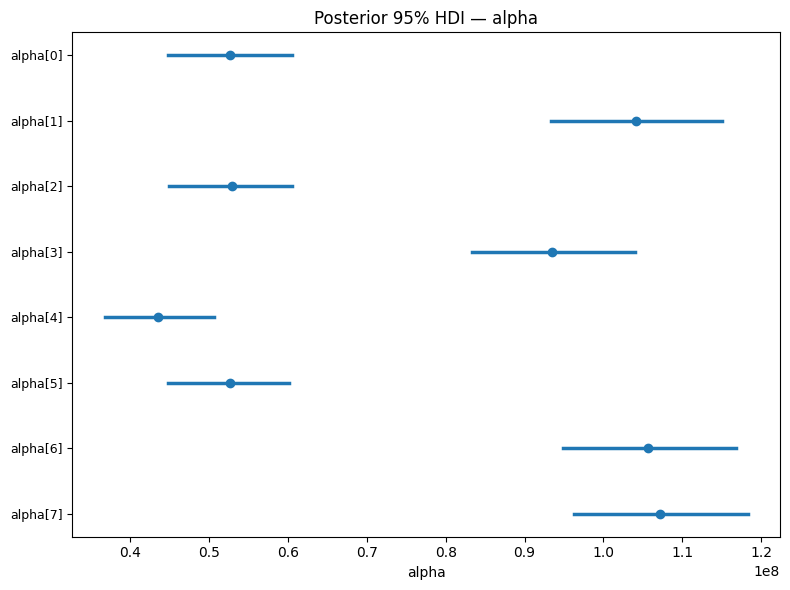

In [39]:
sum_alpha = az.summary(poi_glm1_data, var_names=["alpha"], hdi_prob=0.95)

labels = sum_alpha.index.to_list()
mean = sum_alpha["mean"].values
low = sum_alpha["hdi_2.5%"].values
high = sum_alpha["hdi_97.5%"].values
y = np.arange(len(labels))

plt.figure(figsize=(8, max(6, 0.28 * len(labels))))

for k in range(len(labels)):
    plt.plot([low[k], high[k]], [y[k], y[k]], lw=2.5, color="tab:blue")
    plt.plot(mean[k], y[k], "o", color="tab:blue")

plt.yticks(y, labels, fontsize=9)
plt.xlabel("alpha")
plt.title("Posterior 95% HDI — alpha")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
